# `I. Mesh Processing` 
This .pynb file reads a colored model file `./inter_results/htrap.stl`, and assigns a name for each color(thus for each electrode). The result is stored in `./inter_results/mesh_result.pkl`.

In this file we name different electrodes and refine the meshes. The size of mesh determines the accuracy in next step. You should set the mesh finer and finer until the result converges. Also, you can set the mesh finer and test the convergence.

## (1) color your electrodes (in fusion 360) and export stl
First of all, you have a trap model in fusion 360 project, for example, `./f3d/htrap_overhang_9x5mm.f3d`. Here we use different color to identify different electrodes(STL file stores color for each mesh). In fusion 360, you can assign different appearance for different electrodes. We recommend to use ../../bemCol_lib/bemCol.adsklib for different electrodes. Same color for two electrodes means they are treated as the same electrode. Then we get `./f3d/htrap_overhang_9x5mm_my_colored.f3d`

Then export to an stl file in fusion360 file>export tab and move the file in `./inter_results`. We export our stl in mm, so we set the mesh unit to mm. 

Furthurmore, it's our convention to use unit mm in our traps. e.g. [Electric field] = V/mm , [harmonic confining potential] = V/mm^2.so we set 

In [313]:
zl_position = -220.001

In [314]:
# this is the unit for our Mesh structure
# in the following code, this is the default unit for python variables
#units 
mesh_unit = 1e-3

Additional notes (from Wenhao):
* Why use standard color? We define a set of standard color lib `../../../bemCol_lib/bemCol.adsklib` for two reasons: 1. when exporting to .stl file, fusion 360 will compress 0-256 color(RGBA32) into 0-32 color(RGBA16), which means that some similar colors in fusion 360 will become same color after export to .stl file. Our standard color lib avoid this problem. 2.If you use .stl file exported from fusion 360 DIRECTLY, naming the electrodes would be very convinient. If you use other apps such as Inventor or Meshlab to generate .stl file, you can ignore the second reason because color encoding are quite different in different apps



## (2) assign a name for each color

In [315]:
import pickle
import numpy as np
import matplotlib as mpl
import sys
from utils.helper_functions import *
from bem.bemColors_lib.bemColors import bemColors
from bem import Electrodes, Sphere, Mesh, Grid, Configuration, Result, Box
# load stl geometry file
from bem.formats import stl
# stl_path = "roughness/"+"basic_excitation"+".stl"  


#radius is the radius of the sphere from the ions location to generate a finer
#electrode mesh
radius= 500e-3
#'area' is the area of the triangles inside the sphere
area = 1e-4
# file = 'mit_charge'
# file = 'htrap_overhang_taper_2'
# file_out = 'htrap_overhang_taper_el3'
# stl_path = 'inter_results/taper_overhang/'+file+'.stl'
# fout_name = 'inter_results/taper_overhang/'+file_out+'_'+str(radius)+'_'+str(area)+'.pkl'


file_out = 'htrap'
stl_path = 'inter_results/htrap/htrap.stl'
fout_name = 'inter_results/htrap/'+file_out+'_'+str(radius)+'_'+str(area)+'.pkl'


module_path = os.path.abspath('')


s_nta = stl.read_stl(open(stl_path, "rb"))

Firstly, we print all the colors appear in the stl file. If a color is of standard colors in `bemCol.adsklib` or named manually by function `bemCol.set_my_color()`, then the color will appear in a straightforward name, such as `bem0`,`bem1` ...... . Otherwise, the color will simply be named as `'_unkCol0'` , `'_unkCol1'`, ... 

notes
* try to comment out the line of `ele_col.set_my_color()` in the following block, name `'_unkCol0'` will appear.

In [316]:
ele_col = bemColors(np.array(list(set(s_nta[2]))),('fusion360','export_stl'))
ele_col.set_my_color(value = (178,178,178),cl_format = ('fusion360','export_stl','RGBA64'),name = 'self_defined')
ele_col.print_stl_colors()

COLORS in the stl:
['bem6']
['bem13']
['bem19']
['bem11']
['bem17']
['bem15']
['bem30']
['bem1']
['bem12']
['bem5']
['bem25']
['bem18']
['bem16']
['bem3']
['bem7']
['bem9']
['bem2']
['bem4']
['bem20']
['bem10']
['bem14']
['bem8']
['bem21']
['_unkColor0']
TOTAL COLORS:  24


Next, you need to assign a name for each color that appeared above. With standard colors defined in `bemCol.adsklib`, the correspondence between color and electrode is clear, which make it easy for this step. You can also comment out some `ele_col.set_color_name()`, run all the codes again and observe the missing part in the printed figure, which corresponds to the electrode you comment out. The second method also serves as a double check. Besides, parameter in `stl.stl_to_mesh()` can be set as `quiet = False` to check whether the program reads planes correctly.

In [317]:
# assign a name for each color
# taper htrap 2022
# assign a name for each color

# In od[key] = value, key is the color from the Fusion360 color library we made
# value assigns a specific name to that color in this program. 
# In future version, we may want to consider getting rid of this step for simplification
# then you just assign the color in fusion 360 and be done with it. The only concern there is you
from collections import OrderedDict
od = OrderedDict()
od['bem1']='DC1'
od['bem2']='DC2'
od['bem3']='DC3'
od['bem4']='DC4'
od['bem5']='DC5'
od['bem6']='DC6'
od['bem7']='DC7'
od['bem8']='DC8'
od['bem9']='DC9'
od['bem10']='DC10'
od['bem11']='DC11'
od['bem12']='DC12'
od['bem13']='DC13'
od['bem14']='DC14'
od['bem15']='DC15'
od['bem16']='DC16'
od['bem17']='DC17'
od['bem18']='DC18'
od['bem19']='DC19'
od['bem20']='DC20'
od['bem21'] = 'DC21'
od['bem25'] = 'RF'
od['bem30'] = 'gnd'
for key in list(od.keys()):
    ele_col.color_electrode(color=key,name=od[key])

# print colors still with no name. These meshes will be neglected in the code below. 
ele_col.drop_colors()

# read stl into mesh with electrode names
# unnamed meshes will not be imported at all

mesh = Mesh.from_mesh(stl.stl_to_mesh(*s_nta, scale=1,
    rename=ele_col.electrode_colors, quiet=True))


dropping color ['_unkColor0']
TOTAL COLORS DROPPED:  1
dropping 20083


## (3) remesh

In this step, we generate triangle mesh with constraints. The meshes are 2-dimensional triangles on the surface of electrodes. The region enclosed by constraint shape can have finer mesh. Triangulation is done by `triangle` C library. Folowing variables are all in unit `mesh_unit` now.

Our remesh strategy consists of two steps of triangulation: 
1. global triangulation without constraint. This step eliminate some long and sharp triangles by combining and dividing, and obtains a coarse grain triangulated model.
2. local triangulation with constraint. This step refines each triangles in step 1, the triangle density is defined by `mesh.areas_from_constraints

parameters in the below code block should be tuned specificly for different trap geometries.`

In [318]:
# here we define a spherical constriant zone:
# xl = 57.7*1e-3
# yl = -3.5*1e-3
# zl = 72.5*1e-3

#here is the location that will be the reference point for further meshing
#usually, this is the ion's location, specified in appropriate units (usually millimeters)
zl = zl_position*1e-3
yl = 75*1e-3
xl = 3.75*1e-3


mesh.triangulate(opts="",new = False)

# for z in np.arange(-400e-3,700e-3,100e-3):
print('first triangulation:')
# for z in np.arange(-200e-3, 200e-3, 50e-3):
rad = radius*1
inside=area*30
outside=1
mesh.areas_from_constraints(Sphere(center=np.array([xl,yl,zl]),radius=rad, inside=inside, outside=outside))
mesh.triangulate(opts="a2Q",new = False)

# # what happened to this feature (Box)? is this on bem savio?
# # mesh.areas_from_constraints(Box(start=-0.5, end= 0.5,inside=inside, outside=outside))



# areas_from_constraints specifies sphere with finer mesh inside it.
#  "inside", "outside" set different mesh densities. 
print('second triangulation:')
rad =radius*0.5
inside=area*2
outside=1e4
mesh.areas_from_constraints(Sphere(center=np.array([xl,yl,zl]),radius=rad, inside=inside, outside=outside))
mesh.triangulate(opts="q5Q",new = False)

# save base mesh to a pickle file
# with open(fout_name,'wb') as f:
#     data = (mesh_unit,
#             xl,
#             yl,
#             zl,
#             mesh,
#             list(od.values()))
#     pickle.dump(data,f)

start triangulate RF
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
finish triangulate RF
start triangulate DC21
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
finish triangulate DC21
start triangulate DC2
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
finish triangulate DC2
start triangulate DC7
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
finish triangulate DC7
start triangulate DC11
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr
final opts zr

Mesh([('RF',
        <bem.triangulation.Triangulation at 0x288fd592910>]),
      ('DC21',
        <bem.triangulation.Triangulation at 0x288fd08fdc0>]),
      ('DC2',
        <bem.triangulation.Triangulation at 0x2885c996520>]),
      ('DC7',
        <bem.triangulation.Triangulation at 0x288fce21a30>]),
      ('DC11',
        <bem.triangulation.Triangulation at 0x2885c9a24f0>]),
      ('DC12',
        <bem.triangulation.Triangulation at 0x28900538fa0>]),
      ('DC13',
        <bem.triangulation.Triangulation at 0x288ff2f1220>]),
      ('DC14',
        <bem.triangulation.Triangulation at 0x2885c976580>]),
      ('DC15',
        <bem.triangulation.Triangulation at 0x2885c976f40>]),
      ('DC16',
        <bem.triangulation.Triangulation at 0x288fd5a1940>]),
      ('DC17',
        <bem.triangulation.Triangulation at 0x288fd577340>]),
      ('DC18',
        <bem.triangulation.Triangulation at 0x288fd577dc0>]),
      ('DC19',
        <bem.triangulation.Triangulation at 0x288fd587940>]),
   

In [319]:
# save base mesh to a pickle file
with open(fout_name,'wb') as f:
    data = (mesh_unit,
            xl,
            yl,
            zl,
            mesh,
            list(od.values()))
    pickle.dump(data,f)

# DIVIDER 

# `II. Field Simulation` 
This .pynb file reads `./inter_results/mesh_result.pkl` generated by `./I_Mesh_Processing.ipynb`, and simulates electric field distribution. The result is stored in `./inter_results/field_result.pkl`.

In this file we compute electric field or potential on some spatial points(called `grid`) for all electrode voltage configurations(i.e. one eletrode is 1V and the rest 0V).Major calculations calls `fastlap` C library which uses a pre-conditioned, adaptive, multipole-accelerated algorithm for solving Laplace problem. Two parameters control multipole acceleration.
+ num_mom, the number of multipole
+ num_lev, the number of levels in the hierarchical spatial decomposition.  
num_lev=1 means direct computation without multipole acceleration. See fastlap ug.pdf and README.rst.


In `run_job` function, `job` is `Configuration` instance and `grid` is discretirized spatial grid (not the mesh). The general workflow (also the routine of BEM method) are:  
1. `solve_singularities()` solves charge distributions by iterative methods to make it consistent with one electrode at 1V and others at 0V (unit potentials). `adapt_mesh()` refines meshes adaptively to achieve certain precision while solving sigulartities.
2. Compute potentials on given grid points by `simulate()`, based on the charge distributions gotten previously.
3. Potential data of each unit potential are saved seperately to a `Result` instance, and also export to VTK files.
4. Return total accumulated charge per electrode in the end.

notes:
* here we invoke `multiprocessing.set_start_method("fork")` for compatibility with python version 3.9
* This is the most time consuming part in our workflow. Running following codes in a `.py` file instead of `.ipynb` may be helpful. Closing other apps in your laptop is helpful. Using HPC is also an option. 
* for reference, this file in my laptop(macbook pro, 2 physical kernels) runs 800s
* This `.ipynb` file will generate a `./.vtk` file for intermediate files, which can be simply ignored.

## (1) import the python packages needed for the script



In [320]:
from time import time
import pickle
import numpy as np
import os
import pyvista as pv
import sys
import vtk
sys.path.append('/home/sqip/Documents/github/bem')
from bem import Electrodes, Sphere, Mesh, Grid, Configuration, Result
import multiprocessing 
# multiprocessing.set_start_method("fork")
from utils.helper_functions import *

## (2) import the mesh saved from I_Mesh_Processing
This should correspond to the same name was exported during mesh_processing. The reason this is even an option is in case you want to load in a different saved mesh. 

In [321]:
radius= 500e-3
area =1e-4
file = 'htrap'
file_in_name = 'inter_results/htrap/'+file+'_'+str(radius)+'_'+str(area)+'.pkl'
file_out_name = 'inter_results/htrap/'+file+'_'+str(radius)+'_'+str(area)+'_simulation'
vtk_out = "inter_results/htrap/.vtks/"+file

# file_out = 'htrap_overhang_taper_el3'
# stl_path = 'inter_results/taper_overhang/'+file+'.stl'
# file_in_name = 'inter_results/taper_overhang/'+file_out+'_'+str(radius)+'_'+str(area)+'.pkl'
# file_out_name = 'inter_results/taper_overhang/'+file_out+'_'+str(radius)+'_'+str(area)+'_simulation_tall_rough'
# open the mesh that will be used for simulation
with open(file_in_name,'rb') as f:
    mesh_unit,xl,yl,zl,mesh,electrode_names= pickle.load(f) # import results from mesh processing

## (2) define grid
Here, we define some spatial points for simulation field, called 'grid'.
The grid is typically a 3-d cube centered on the trapping location.
* s is the unit step for the spatial points
* Lx, Ly, Lz are the dimensions of the 3-d cube
* sx, sy, sz are the step size along each dimension
* nx, ny, nz are the number of points to be simulated along each dimension
* `Grid` is the function imported from the bem package that will be inputted into the simluation

In [322]:
with open(file_in_name,'rb') as f:
    mesh_unit,xl,yl,zl,mesh,electrode_names= pickle.load(f) # import results from mesh processing
# grid to evalute potential and fields atCreate a grid in unit of scaled length mesh_unit. Only choose the interested region (trap center) to save time.
Lx, Ly, Lz = 11*1e-3,11*1e-3,11*1e-3# in the unit of scaled length mesh_unit
# xl,yl,zl = -3.75*1e-3,72*1e-3,450*1.0e-3
xl,yl,zl = 3.75e-3,75e-3,zl_position*1e-3
s = 1e-3
sx,sy,sz = s,s,s
print("done")
# ni is number of grid points, si is step size. To  on i direction you need to fix ni*si.
nx, ny, nz = [int(Lx/sx),int(Ly/sy),int(Lz/sz)]
print("Size/l:", Lx, Ly, Lz)
print("Step/l:", sx, sy, sz)
print("Shape (grid point numbers):", nx, ny, nz)
grid = Grid(center=(xl,yl,zl), step=(sx, sy, sz), shape=(nx,ny,nz))
# Grid center (nx, ny ,nz)/2 is shifted to origin
print("lowval",grid.indices_to_coordinates([0,0,0]))
print("Grid center index", grid.indices_to_coordinates((nx/2,ny/2,nz/2)))
print("gridpts:",nx*ny*nz)
center = (xl,yl,zl)
step = (sx,sy,sz)
shape = (nx,ny,nz)
# xyz = np.array([np.linspace(c-s*(h-1)/2., c+s*(h-1)/2.,h)
#                 for c, s, h in zip(center, step, shape)])

done
Size/l: 0.011 0.011 0.011
Step/l: 0.001 0.001 0.001
Shape (grid point numbers): 11 11 11
lowval [-0.00125   0.07     -0.225001]
Grid center index [ 0.00425   0.0755   -0.219501]
gridpts: 1331


## (2) run jobs
`pmap.multiprocessing.Pool(processes).map(job,list)` is used to do several simulations in parallel (depends what you define as parallel). 

`Pool(number)` creates a set of worker processes, called a pool, to submit tasks to. When a job is submitted to a worker process, the worker process executes that task. <b>Each worker process is associated with its own CPU core</b> which means the number of worker processes in the pool is the number of parallel computations that can be performed. <b>number</b> is the number of worker processes to start. 

In other words, if you want to use only 1 core at a time, write Pool(1), if you want 2 cores write Pool(2). If no number is given, `Pool` will create as many worker processes as there are cores on the computer. This speeds things up (you can use all cores simulatneously), but it is important to point out that since each worker process will be requesting RAM, this will consume more memory on your computer than Pool(1). If the total RAM requested exceeds what your computer has, <b>you're gonna have a bad time</b>. One of two things will likely happen- first is that your computer will try to start using 'swap space' which is using disk memory as RAM which will slow down the computation significantly- this is not obvious unless you are looking at the resources being used by your computer (look for normal memory used and swap memory used on system monitor). Second is that your computer wil crash because the worker processes have consumed all the memory. 

`Pool.map`(<b>job</b>,<b>jobs_list</b>) takes two arguments:
* <b>job</b> is the python function that will be turned into a job to be executed by the worker processes
* <b>jobs_list</b> is a list where each item in the list is a set of arguments to be provided to the function when creating a job

The worker processes then execute any job sent to the pool. 

In [323]:
jobs = list(Configuration.select(mesh,'DC.*','RF'))    # select() picks one electrode each time.
# run the different electrodes on the parallel pool
pmap = multiprocessing.Pool(2).map # parallel map
#pmap = map # serial map
# t0 = time()
# range(len(jobs))
def run_map():
    pmap(run_job, ((jobs[i], grid, vtk_out,i,len(jobs)) for i in np.arange(len(jobs))))
    # print( "Computing time: %f s"%(time()-t0))
    # run_job casts a word after finishing ea"ch electrode.

run_map()

## (3) save simulation results

In [324]:
electrode_names = ['DC1','DC2','DC3','DC4','DC5','DC6','DC7','DC8','DC9','DC10',
                   'DC11','DC12','DC13','DC14','DC15','DC16','DC17','DC18','DC19','DC20','DC21',
                   'RF']
write_pickle(vtk_out,file_out_name,grid,electrode_names)

DC1
DC2
DC3
DC4
DC5
DC6
DC7
DC8
DC9
DC10
DC11
DC12
DC13
DC14
DC15
DC16
DC17
DC18
DC19
DC20
DC21
RF


In [325]:
result = Result.load(vtk_out, 'DC1', 'vtk')
print(vtk_out)

inter_results/htrap/.vtks/htrap


In [326]:
length_scale = 1e-3
epsilon_0 = 8.85e-12
electrode_index = np.where(result.configuration.potentials==1)[0][0]
electrode_capacitance_cgs = result.configuration.collect_charges()[electrode_index]
electrode_capacitance_si = 4*np.pi*epsilon_0*length_scale
electrode_capacitance_picofarads = electrode_capacitance_si*1e12
print(electrode_capacitance_picofarads)

0.11121237993707869


## (4) view simulation results
The results can be viewed in an interactive 3-d plot using the package pyvista

In [327]:
# "the last simulated mesh was for mesh radius 500e-3mm and max triangle area 3.125e-5 mm"
# ele = 'DC16'
# data_name = "%s_%s.vtk" % (vtk_out, ele)
# data = pv.UniformGrid(data_name)
# scalar_name = 'potential'
# avals = data[scalar_name]
# range = avals.max()-avals.min()
# input_range = [avals.min(),avals.min()+range]
# Result.view(vtk_out, ele) # add electrode name between '' for result view

"the last simulated mesh was for mesh radius 500e-3mm and max triangle area 3.125e-5 mm"
ele = 'DC16'
data_name = "%s_%s.vtk" % (vtk_out, ele)
data = pv.ImageData(data_name)  # Changed from pv.UniformGrid to pv.ImageData
scalar_name = 'potential'
avals = data[scalar_name]
range = avals.max()-avals.min()
input_range = [avals.min(),avals.min()+range]
#Result.view(vtk_out, ele) # add electrode name between '' for result view

In [328]:
# for x in np.arange(0,4):
data_name = "%s_%s.vtk" % (vtk_out, 'RF')
import pyvista as pv 
data = pv.ImageData(data_name)
scalar_name = 'potential'

avals = data[scalar_name]
input_range = [-0.2,1.0]
#Result.view(vtk_out, 'RF') # add electrode name between '' for result view

In [329]:


plotter = pv.Plotter(notebook = False)
prefix = vtk_out
name = 'DC15'
base_mesh_name = "%s_mesh.vtk" % prefix
mesh_name = "%s_%s_mesh.vtk" % (prefix, name)

def callback_func(electrode_name):
    idc_name = np.where(mesh.cell_data['electrode_name'] == electrode_name)
    selected_faces = mesh.faces.reshape(-1, 4)[idc_name]
    selected_mesh = pv.PolyData(mesh.points, faces = selected_faces)
    plotter.add_mesh(selected_mesh, name = 'select', style = 'wireframe', line_width=5, color='black')

if os.access(mesh_name, os.R_OK):
    mesh = pv.PolyData(mesh_name)
    charge_min = mesh.cell_data['charge'].min()
    charge_max = mesh.cell_data['charge'].max()
    charge_absmax = abs(mesh.cell_data['charge']).max()

    Ncolors = len(pv.LookupTable('bwr').values)
    Ncolors_half = int(Ncolors/2)
    mid_to_left = int(np.rint(charge_min/charge_absmax * Ncolors_half))
    mid_to_right = int(np.rint(charge_max/charge_absmax * Ncolors_half))
    cmap_values = pv.LookupTable('bwr').values[Ncolors_half + mid_to_left : Ncolors_half + mid_to_right]
    cmap = pv.LookupTable(values = cmap_values, scalar_range = (charge_min, charge_max))
    # cmap = pv.LookupTable(cmap = 'bwr', scalar_range = (-4, 4))
    plotter.add_mesh(mesh, scalars = 'charge', cmap = cmap, show_edges = True,show_scalar_bar=False)
    electrode_list = list(np.unique(mesh.cell_data['electrode_name']))
    # plotter.add_text_slider_widget(callback_func, electrode_list,  pointa=(0.05, 0.9), pointb=(0.3, 0.9), interaction_event = 'always')
elif os.access(base_mesh_name, os.R_OK):
    mesh = pv.PolyData(base_mesh_name)
    # colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', 
    #           '#2ca02c', '#98df8a', '#d62728', '#ff9896', 
    #           '#9467bd', '#c5b0d5', '#8c564b', '#c49c94', 
    #           '#e377c2', '#f7b6d2', '#7f7f7f', '#c7c7c7', 
    #           '#bcbd22', '#dbdb8d', '#17becf', '#9edae5',
    #           # above is colormap tab20 from matplotlib
    #           '#0000FF', '#7FFF00', '#4B0082', '#FF00FF', '#800000', '#FFFF00', '#B8860B', '#F0E68C', '#FFFFFF',
    #           # above is blue, chartreuse, indigo, magenta, maroon, yellow, darkgoldenrod, khaki, white
    #           ]
    plotter.add_mesh(mesh, scalars = 'electrode_name', 
                    scalar_bar_args = {'interactive': True, 'label_font_size': 15}, 
                    # cmap = colors, 
                    show_edges = True)
    electrode_list = list(np.unique(mesh.cell_data['electrode_name']))
    plotter.add_text_slider_widget(callback_func, electrode_list,  pointa=(0.05, 0.9), pointb=(0.3, 0.9), interaction_event = 'always')

data_name = "%s_%s.vtk" % (prefix, name)
if os.access(data_name, os.R_OK):
    data = pv.ImageData(data_name)
    if 'field_square' in data.point_data.keys():
        scalar_name = 'field_square'
    else:
        scalar_name = 'potential'
    iso_surfaces = data.contour(isosurfaces = 1000, scalars = scalar_name
                            )
    plotter.add_mesh(iso_surfaces, cmap = 'viridis', opacity = 1,show_scalar_bar=False)

# plotter.show_bounds()
plotter.add_camera_orientation_widget()
plotter.set_background('black', top='white')
#plotter.show()

# DIVIDER 2

# `III. Multipole Expansion` 
This .pynb file reads `./inter_results/field_result.pkl` generated by `./II_Field_Simulation.ipynb`, and analyzes the field distribution result. This analysis can be specific according to your own need. Here, as an example, we focus on multipole expansion coefficient. 

## (1) import electric field and set parameters for it.

In [330]:
import sys
sys.path.append('../../')
import scipy.ndimage as im
from scipy.optimize import lsq_linear
import pickle
# add multipoles package path
import pandas as pd
from utils.multipoles import MultipoleControl
from utils.plottingfuncns import *

from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm
from collections import OrderedDict
module_path = os.path.abspath('')
from utils.helper_functions import *


## Import Simulated Data

In [331]:
###### loading in pickle file ###############################
# import data, and define parameters
module_path = os.path.abspath('')

radius= 500e-3
area = 1e-4

path = module_path+'/inter_results/htrap/htrap_'+str(radius)+'_'+str(area)+'_simulation.pkl'
# el2
zl = ( zl_position + 0.0 ) *1e-3
# el3.5
# zl = -210*1e-3
# el4
# zl = -100*1e-3

#other simulations
########################################################################################################################
# path = module_path+'/inter_results/htrap/charge_mit_charge_0.1_5e-06_simulation.pkl'
# path = module_path+'/inter_results/htrap/simple_roughness_1.0_2e-06_simulation.pkl'
# file_out = 'htrap_overhang_taper_el3'
# path = module_path+'/inter_results/taper_overhang/'+file_out+'_'+str(radius)+'_'+str(area)+'_simulation_tall_rough.pkl'
########################################################################################################################


print(str(area))
# file_out = 'htrap_el4'
# path = module_path+'/inter_results/htrap/'+file_out+'_'+str(radius)+'_'+str(area)+'_simulation.pkl'


f = open(path, 'rb')
trap = pickle.load(f)
# trap['X'], trap['Y'], trap['Z'] are the position coordinates for the simulated volume
print("x positions of the simulation")
print(trap['Z'])
#trap['electrodes'] is a dictionary with keys that correspond to each electrode
print("electrodes simulated")
print(trap['electrodes'].keys())
#plugging in one of the keys, in this case 'DC1,' gives access to the 3-dimensional 
#simulated potentials for that electrode while 'position' is just a refeerence location
# for easy plotting using matplotlib that can be set anytime.  
print("shape of the simulated potential voltages for DC1")
# print(np.shape(trap['electrodes']['DC1']['potential']))
# print(trap['electrodes']['DC1']['position'])
#the 'potential' for 'RF' is really the |E|^2, which can be used to generate the pseudopotential
#note that the units are V/mm^2- all the units in these files are mm b/c that's what fusion360 exports,
#that coordinate system is continued just for consistency. 
print("shape of the simulated |E|^2 for RF")
print(np.shape(trap['electrodes']['RF']['potential']))

print("path to the pkl file", path)

#############################################################

0.0001
x positions of the simulation
[-0.225001 -0.224001 -0.223001 -0.222001 -0.221001 -0.220001 -0.219001
 -0.218001 -0.217001 -0.216001 -0.215001]
electrodes simulated
dict_keys(['DC1', 'DC2', 'DC3', 'DC4', 'DC5', 'DC6', 'DC7', 'DC8', 'DC9', 'DC10', 'DC11', 'DC12', 'DC13', 'DC14', 'DC15', 'DC16', 'DC17', 'DC18', 'DC19', 'DC20', 'DC21', 'RF'])
shape of the simulated potential voltages for DC1
shape of the simulated |E|^2 for RF
(11, 11, 11)
path to the pkl file c:\msys64\home\artiq\repos\integrated_photonics_bem\examples\Integrated_photonics/inter_results/htrap/htrap_0.5_0.0001_simulation.pkl


In [332]:

###### setting up multipole expansion @ trap location #######
#xl, yl, zl define the origin at which we will do the multipole expansion
#i.e. they define where you want to trap

#strs are the string names of your DC electrodes (copy from loading pickle,
#I wrote it a second time so that the code runs in case you comment out that code)

strs = list(trap['electrodes'].keys())
xl = 3.75*1e-3
yl = 77*1e-3

position = [xl, yl, zl]

#ROI = 'range of interest', I believe
#It defines the volume region over which multipole expansion will be performed.
#nROI is the number of points that make up the dimensions of the volume of the ROI
#I believe it ends up being the indices of the 3-d array that you index so it is dimensionless
nROI = 2
roi = [nROI, nROI, nROI]
order = 2

#controlled electrodes- this will define which electrodes will be used to control your trap
controlled_electrodes = []

## (2) set parameters for multipole expansion
notes:
* new from shuqi's code- 'excl' defines a dictionary of excluded electrodes the dictionary index (left of colon)  is the electrode you want to exclude its value (right of colon) defines what you want to set it to if you set it to "gnd" it will always set the voltage of that DC to 0 if you set it to "DCx" it will always set the voltage of that DC to be the same as DCx this is in case you have trap shorts, if you don't need it just don't include the indices

In [333]:
# excl = {
#     "DC9":"gnd",
#     "DC11":"gnd",
#     "RF":"gnd",
#     "DC0":"gnd"
#     "DC2":"DC3"

# }

# RF should be set to ground to do a multipole decomposition of the DC fields. 
# Setting RF to ground means that no DC bias is applied to the RF. 
excl = {"RF":"gnd",
        "DC20": "gnd",  # This electrode will be grounded (0V)
        # "DC15": "gnd",  # This electrode will be grounded (0V)
    }

#build the controlled electrodes list, given the constraints of the 'excl' list
for electrode in strs:
    if electrode in excl and excl[electrode] != "gnd":
        trap['electrodes'][excl[electrode]]["potential"] = trap['electrodes'][excl[electrode]]["potential"] + \
                                                           trap['electrodes'][electrode]["potential"]
    elif electrode not in excl:
        controlled_electrodes.append(electrode)

#which multipoles you want to include in multipole calculations
used_order1multipoles = ['Ex', 'Ey', 'Ez']
used_order2multipoles = ['U1', 'U2', 'U3','U4','U5']
used_multipoles = used_order1multipoles + used_order2multipoles
print(np.shape(trap['electrodes'][electrode]["potential"]))

# create MultipoleControl object
s = MultipoleControl(trap, position, roi, controlled_electrodes, used_multipoles, order)
s.electrode_positions = OrderedDict([('DC1', [0, 1]), ('DC2', [0, 2]), ('DC3', [0, 3]), ('DC4', [0, 4]), 
             ('DC5', [0, 5]), ('DC6', [0, 6]), ('DC7', [0, 7]), ('DC8', [0, 8]), 
             ('DC9', [0, 9]), ('DC10', [0, 10]), ('DC11', [2, 1]), ('DC12', [2, 2]), 
             ('DC13', [2, 3]), ('DC14', [2, 4]), ('DC15', [2, 5]),('DC16', [2, 6]),
             ('DC17', [2, 7]),('DC18', [2, 8]),('DC19', [2, 9]),('DC20', [2, 10]),
             ('DC21', [1, 1]),('RF', [1, 2])])
print(controlled_electrodes)

#     return s
# s,used_multipoles = generate_s(excl)
###############################################################

(11, 11, 11)
['DC1', 'DC2', 'DC3', 'DC4', 'DC5', 'DC6', 'DC7', 'DC8', 'DC9', 'DC10', 'DC11', 'DC12', 'DC13', 'DC14', 'DC15', 'DC16', 'DC17', 'DC18', 'DC19', 'DC21']


## Plotting RF Fields
This shows a contourplot of the RF pseudopoential field, as well as the RF null. 
There is also a section to find the saddle point so that the trap depth can be found. A the simulation volume needs to capture the saddle point for this to work. 

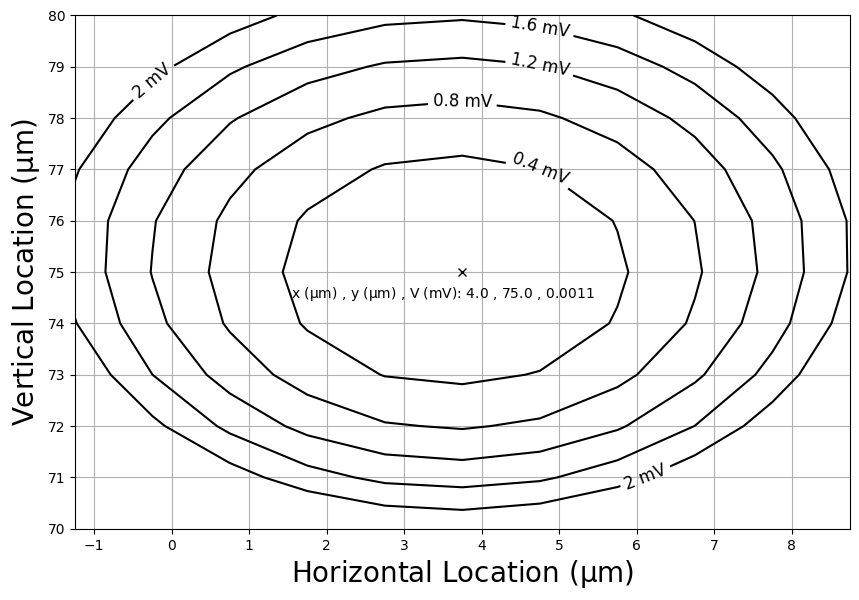

In [334]:
# Generating pseudopotential
##############################################################################################################################
#q = ion charge
#l = units of used to specify simulation grid, should likely be 1 mm
#Omega = trap drive angular frequency
#voltage = RF voltage
#v_to_mV = convert pseudopotential units from volts to millivolts
q = 1.6*1e-19
l = 1e-3
m = 40*1.66054e-27
Omega = 2*np.pi*26.5*1e6
voltage = 1.5*26
v_to_mV = 1000 
# voltage = 50*1.26 for taper trap based on lower radial x  (2.08MHz @ 1.5dbm R&S, ~1.4 W transmitted power)

#generating pseudopotential from simulated |E|^2 of RF field
d = trap['electrodes']['RF']['potential'][:,:,0]*voltage**2*q/(4*m*Omega**2)/l**2*v_to_mV
##############################################################################################################################

# taper trap stuff
##############################################################################################################################
# for taper trap: u2 solution that can be superimposed onto the RF
# u2_soln =\
# [0.322124,0.245919,-2.669645,0.243209,-0.296533,-0.256699,-0.212897,-0.172587,
# -0.136261,-0.111947,-0.260888,-0.391296,-2.656598,-0.378270,-0.208301,-0.181067
# ,-0.149683,-0.115415,-0.089443,-0.072666,-0.374573]
# pot_array = np.zeros(np.shape(trap['electrodes']['RF']['potential'][:,:,0]))
# for i in np.arange(1,21,1):
#     pot_array = pot_array+trap['electrodes']['DC'+str(i)]['potential'][:,:,0]*u2_soln[i]*20
# d = d+pot_array
##############################################################################################################################

# Generate contour plot
##############################################################################################################################
#generate figure to plot RF fields
plt.figure(figsize=(30/3,20/3))

#numInter = number of points used to interpolate between points
#CAUTION: no idea what the interpolation function looks like, so be wary of using the 
# interpolated for quantitative calculations or multipoe decomposition. I only use it
# so I can smooth out out the field to get a basic idea of what the RF looks like when 
# I'm not using many gridpoints in the simulation
# num_inter = 5
# d = im.zoom(d, num_inter)
# x = im.zoom(trap['X'],num_inter)*1e3
# y = im.zoom(trap['Y'],num_inter)*1e3


#d is RF pseudopotential field 
#x , y are the x, y axes
d = d
x = trap['X']*1e3
y = trap['Y']*1e3


#setting contour values
min_val = np.min(d)
max_val =  np.max(d)*0.5
steps = 5
c_range = np.arange(min_val,max_val,(max_val-min_val)/(steps+1))

#plotting contours
cmap = LinearSegmentedColormap.from_list('black', ['black', 'black'])
CS = plt.contour(x,y,np.transpose(d),levels=c_range,cmap=cmap,zorder=2)

#labeling contours
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} mV" if plt.rcParams["text.usetex"] else f"{s} mV"
plt.clabel(CS, CS.levels, inline=True,fmt=fmt,fontsize=12,use_clabeltext=True)
##############################################################################################################################


# Find location of the RF null
##############################################################################################################################
min_value = np.min(d[:,:])
coordinates = np.where(d == min_value)
plt.plot(x[coordinates[0][0]],y[coordinates[1][0]],'kx')
min_x = np.round(x[coordinates[0]],0)[0]
min_y = np.round(y[coordinates[1]],0)[0]
plt.text(min_x-0.5,min_y-0.5,
         r"x ($\mathrm{\mu m}$) , y ($\mathrm{\mu m}$) , V (mV): "
         +str(min_x)+' , '+str(min_y)+' , '+str(np.round(d[coordinates[0][0],coordinates[1][0]],4)),color='k',
         horizontalalignment='center')


#Final Plot Params
##############################################################################################################################
plt.xlabel(r"Horizontal Location ($\mathrm{\mu}$m)",fontsize=20)
plt.grid()
plt.xticks(np.arange(-40,40,10))
plt.yticks(np.arange(0,180,20))
plt.ylabel(r"Vertical Location ($\mathrm{\mu}$m)",fontsize=20)
plt.xticks(np.arange(-5,10,1))
plt.yticks(np.arange(65,85,1))
plt.xlim(3.75-5,3.75+5)
plt.ylim(75-5,75+5)
plt.show()
##############################################################################################################################


In [335]:
# ################# writing to cfile ############################
# #write solution text file (cfile, sqip uses .txt format tho)
# #this will be generated in the 'Electrodes' directory
# s.write_txt('mit_LL_ele5', strs, excl)
# ###############################################################



## (3) compute desired voltage configuration and plot result
height list is a list of places to expand the field generated by each electrode

In [336]:
height_list = trap['Y'][np.arange(nROI,len(trap['Z'])-nROI)]
print(np.arange(nROI,len(trap['Z'])-nROI))
numMUltipoles = len(s.multipole_print_names)
ne = len(s.electrode_names)
multipoles_vs_height = np.zeros((len(height_list), numMUltipoles, ne))
print('height_list:',height_list)
for i, height in enumerate(height_list):
    position1 = [xl, height, zl]
    s.update_origin_roi(position1, roi)
    multipoles_vs_height[i] = np.asarray(s.multipole_expansion.loc[s.multipole_names])

[2 3 4 5 6 7 8]
height_list: [0.072 0.073 0.074 0.075 0.076 0.077 0.078]


## Plotting Multipole Decomposition for electrodes

## Plotting Spherical Harmonic  Decomposition
This plots the spherical harmonic decomposition up to 2nd-order of the multipoles of the fields generated by placing 1V on an electrode specified in electrode_list and ground all others.

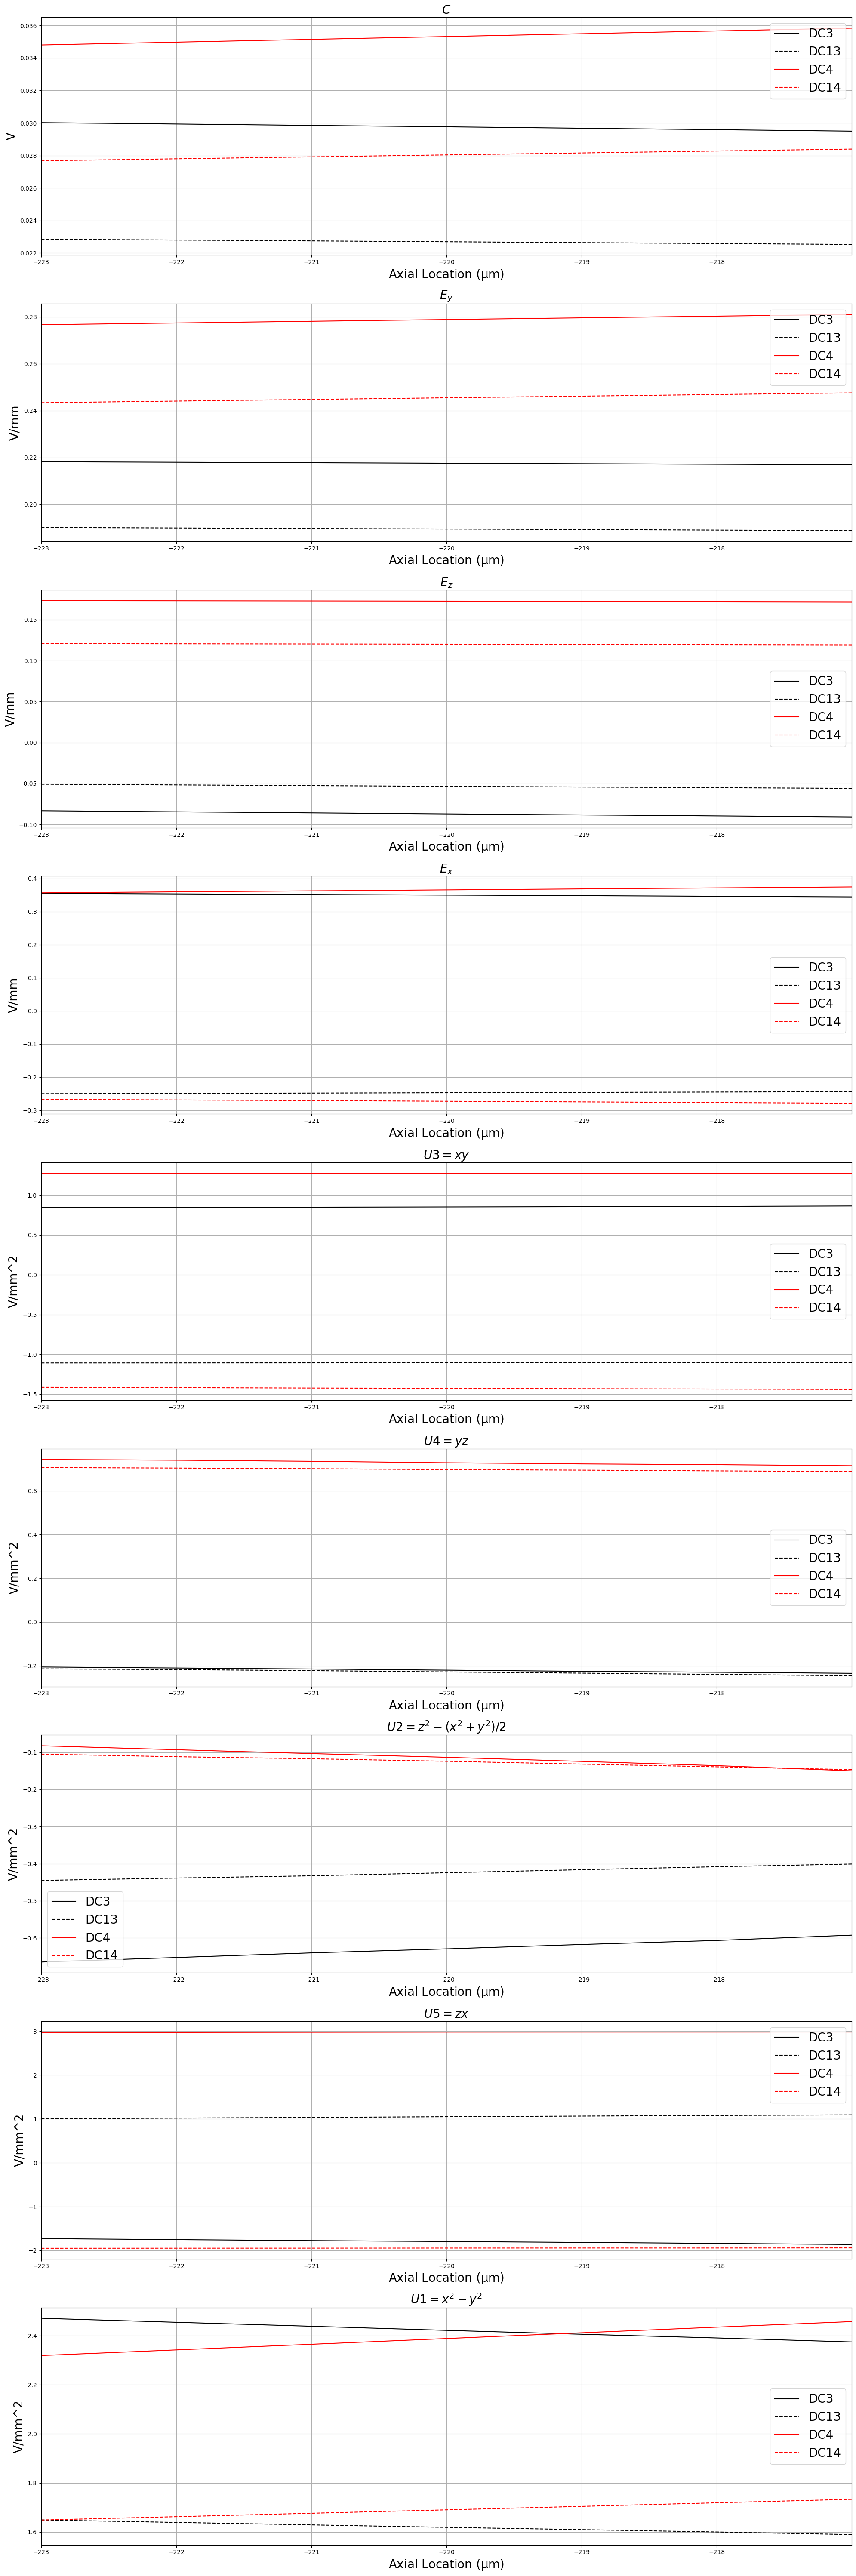

In [337]:
# 'height_list' is the list of the places to do the spherical decomp. of the electrode potential
# 'height_list' currently refers to axial locations
height_list = trap['Z'][2:len(trap['Z'])-2]
numMUltipoles = len(s.multipole_print_names)


ne = len(s.electrode_names)
multipoles_vs_height = np.zeros((len(height_list), numMUltipoles, ne))

for i, height in enumerate(height_list):
    position1 = [xl, yl,height]
    s.update_origin_roi(position1, roi)
    multipoles_vs_height[i] = np.asarray(s.multipole_expansion.loc[s.multipole_names])

size = 20
electrode_list = ['DC3','DC13','DC4','DC14']

fig, ax = plt.subplots(numMUltipoles, 1, figsize=(20, 60))
for i, mul in enumerate(s.multipole_print_names):
    ax[i].set_prop_cycle(linestyle = ['-','--','-','--','-','--','--','--','--','--'],color= ['black','black','red','red','orange','black','blue','purple','red','orange'])
    for ele in electrode_list:
        j = s.electrode_names.index(ele)
        ax[i].plot(height_list*1e3, multipoles_vs_height[:, i, j], label=ele)
        if i == 0:
            ax[i].set_ylabel('V',fontsize=size)
        elif i < 4:
            ax[i].set_ylabel('V/mm',fontsize=size)
        else:
            ax[i].set_ylabel('V/mm^2',fontsize=size)
        ax[i].set_title(mul, fontsize=size)
        ax[i].set_xticks(np.arange(-300,300,1))
        ax[i].set_xlabel(r'Axial Location ($\mathrm{\mu}$m)', fontsize=size)
        ax[i].set_xlim(min(height_list*1e3),max(height_list*1e3))
        ax[i].grid(visible=True)
        ax[i].legend(fontsize=size)
    fig.tight_layout()

## Generating Axial Confinment
Here are plots of the voltage solutions that generate axial confinement. We generate axial confinement by generating a DC field 
that corresponds to a specific 2nd order multipole. The 

multipole_coeffs:  {'Ex': -0.2, 'Ey': 6.0, 'Ez': -0.0, 'U1': 0, 'U2': 6, 'U3': 2.0, 'U4': 0, 'U5': 0}
['DC1', 'DC2', 'DC3', 'DC4', 'DC5', 'DC6', 'DC7', 'DC8', 'DC9', 'DC10', 'DC11', 'DC12', 'DC13', 'DC14', 'DC15', 'DC16', 'DC17', 'DC18', 'DC19', 'DC21']
Bounded solve status: 1 (The first-order optimality measure is less than `tol`.)
max |V| = 9.189311 V (limit 9.9 V)
free multipoles: ['U4', 'U5']
    target      achieved         error
Ex    -0.2 -2.000000e-01 -1.376677e-14
Ey     6.0  6.000000e+00 -1.065814e-14
Ez    -0.0  1.510599e-15  1.510599e-15
U1     0.0 -7.105427e-15 -7.105427e-15
U2     6.0  6.000000e+00  0.000000e+00
U3     2.0  2.000000e+00  7.105427e-15
free multipole results: {'U4': np.float64(0.699628426378446), 'U5': np.float64(-14.576911058424697)}


C:\Users\artiq\AppData\Local\Temp\ipykernel_7880\2873300922.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(s.controlled_elecs, rotation=45, fontsize=12)


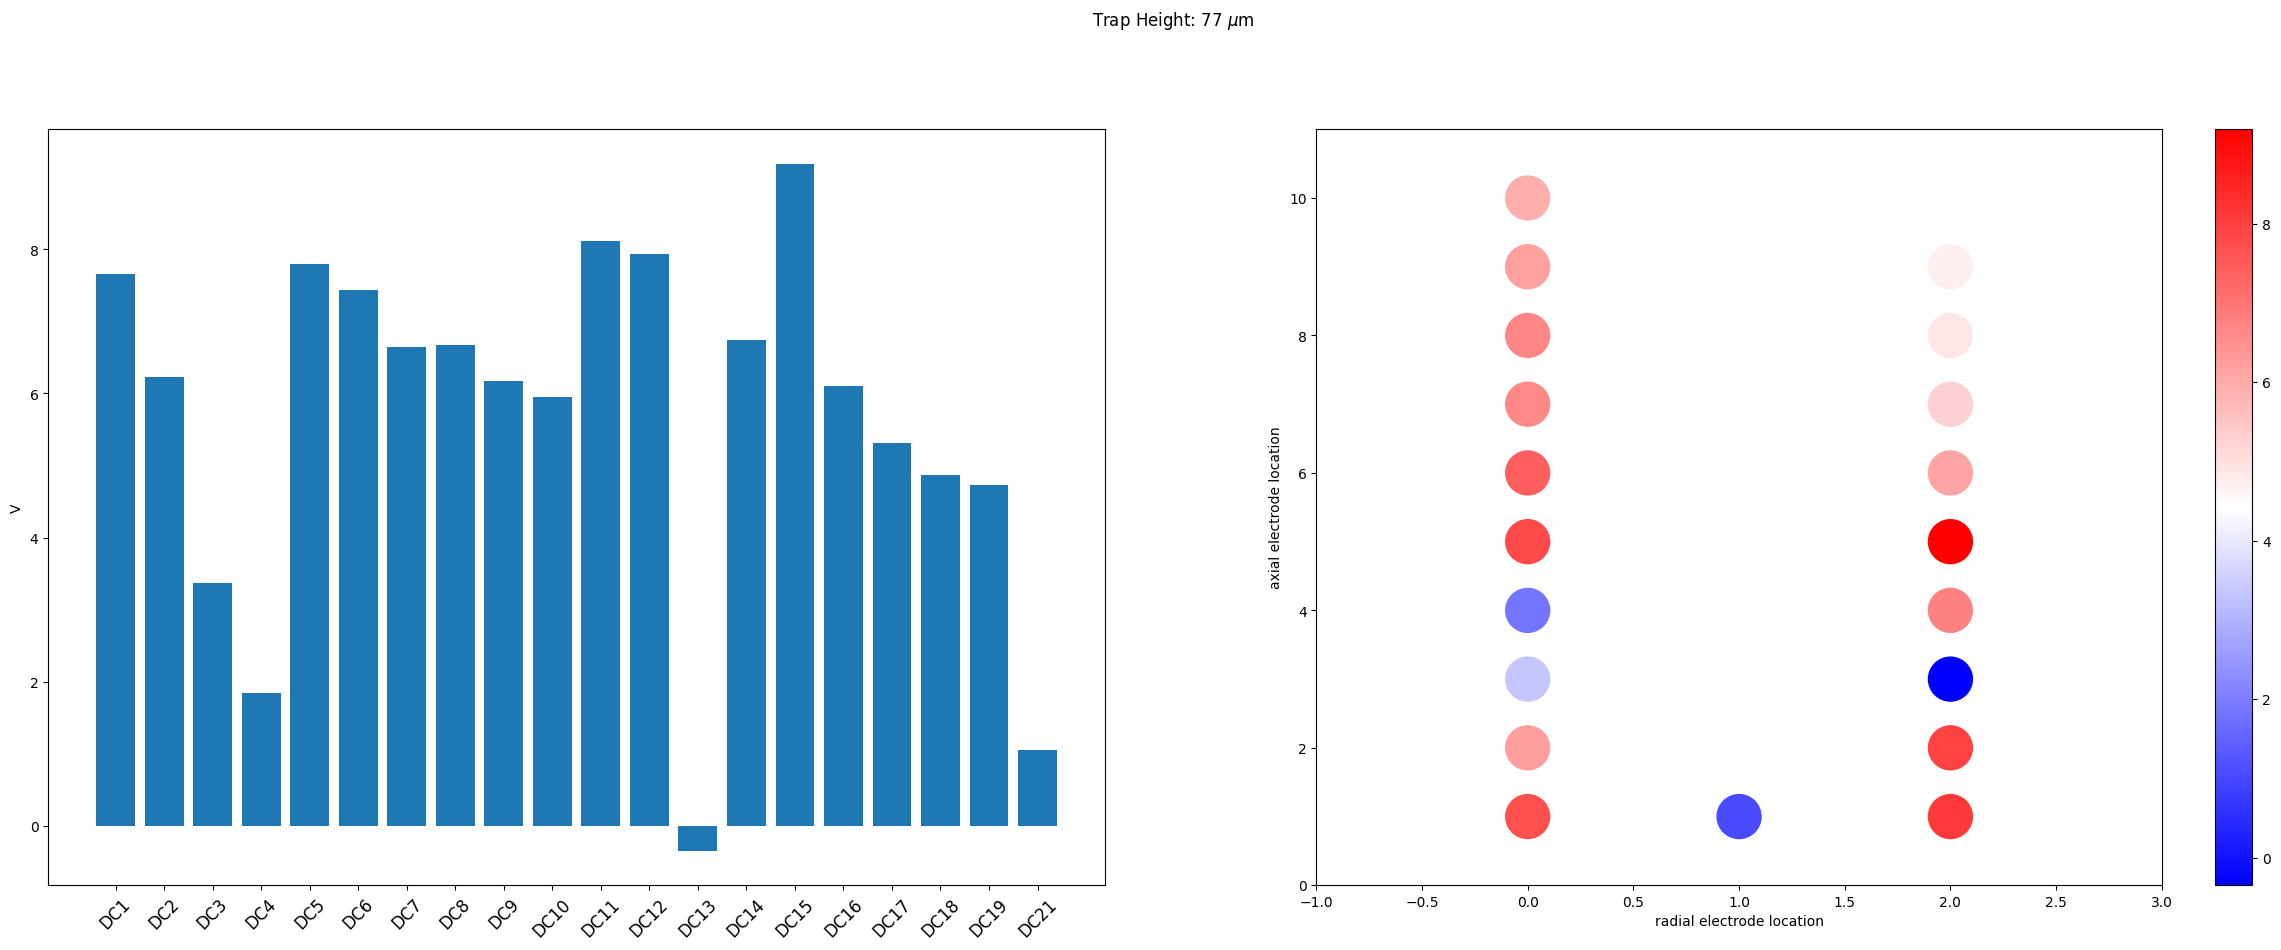

voltages: 
{'DC1': 7.664722055721866, 'DC2': 6.22737031467745, 'DC3': 3.369820343992138, 'DC4': 1.8432207434460464, 'DC5': 7.803416093155897, 'DC6': 7.438136044943514, 'DC7': 6.640057948503748, 'DC8': 6.668661558094947, 'DC9': 6.175939805694413, 'DC10': 5.944521660933598, 'DC11': 8.118558836149539, 'DC12': 7.931938005061539, 'DC13': -0.3474070721617997, 'DC14': 6.744412422485819, 'DC15': 9.189311284116956, 'DC16': 6.104506055201364, 'DC17': 5.313997382673127, 'DC18': 4.87568136611313, 'DC19': 4.733589552010399, 'DC21': 1.0586658480955247, 'DC20': 0.0}
type:  <class 'dict'>

Remapped voltages: 
{'DC21': 7.664722055721866, 'DC20': 6.22737031467745, 'DC19': 3.369820343992138, 'DC18': 1.8432207434460464, 'DC17': 7.803416093155897, 'DC16': 7.438136044943514, 'DC15': 6.640057948503748, 'DC14': 6.668661558094947, 'DC13': 6.175939805694413, 'DC12': 5.944521660933598, 'DC10': 8.118558836149539, 'DC9': 7.931938005061539, 'DC8': -0.3474070721617997, 'DC7': 6.744412422485819, 'DC6': 9.189311284116

In [338]:
def solve_muls_bounded(s, multipole_coeffs, max_voltage=9.9, free_multipoles=("U4", "U5")):
    free_multipoles = set(free_multipoles)
    constrained_multipoles = [
        key for key in s.used_multipoles if key in multipole_coeffs and key not in free_multipoles
    ]

    if not constrained_multipoles:
        raise ValueError("No constrained multipoles selected for bounded solve.")

    A = s.expansion_matrix.loc[constrained_multipoles, s.controlled_elecs].to_numpy(dtype=float)
    b = np.array([multipole_coeffs[key] for key in constrained_multipoles], dtype=float)

    result = lsq_linear(A, b, bounds=(-max_voltage, max_voltage), method="trf")
    if not result.success:
        raise RuntimeError(f"Bounded solve failed: {result.message}")

    voltages = pd.Series(result.x, index=s.controlled_elecs).clip(-max_voltage, max_voltage)
    return voltages, result, constrained_multipoles


def plot_muls(s,xl,zl,roi,height, max_voltage=9.9, free_multipoles=("U4", "U5"), **multipoles):
    position1 = [xl, height * 1e-3, zl]
    s.update_origin_roi(position1, roi)
    multipole_coeffs = {key:multipoles[key.lower()] for key in s.used_multipoles}
    print("multipole_coeffs: ", multipole_coeffs)

    voltages, result, constrained_multipoles = solve_muls_bounded(
        s,
        multipole_coeffs,
        max_voltage=max_voltage,
        free_multipoles=free_multipoles,
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 12))
    fig.suptitle(f'Trap Height: {height:0.0f} $\mu$m')
    ax1.bar(s.controlled_elecs, voltages)
    ax1.set_xticklabels(s.controlled_elecs, rotation=45, fontsize=12)
    ax1.set_ylabel('V')
    print(s.controlled_elecs)
    xpos = [s.electrode_positions[ele][0] for ele in s.controlled_elecs]
    ypos = [s.electrode_positions[ele][1] for ele in s.controlled_elecs]
    plot = ax2.scatter(xpos, ypos, 1000, list(voltages), cmap='bwr')
    fig.colorbar(plot)
    ax2.set_ylabel("axial electrode location")
    ax2.set_xlabel("radial electrode location")
    ax2.set_xlim(min(xpos) - 1, max(xpos) + 1)
    ax2.set_ylim(min(ypos) - 1, max(ypos) + 1)
    plt.subplots_adjust(bottom=0.25)

    voltages_dict = dict(zip(s.controlled_elecs, voltages))
    achieved = s.setVoltages(pd.Series(voltages_dict))

    compare_df = pd.DataFrame({
        "target": [multipole_coeffs[m] for m in constrained_multipoles],
        "achieved": [achieved[m] for m in constrained_multipoles],
    }, index=constrained_multipoles)
    compare_df["error"] = compare_df["achieved"] - compare_df["target"]

    print(f"Bounded solve status: {result.status} ({result.message})")
    print(f"max |V| = {np.max(np.abs(voltages.values)):.6f} V (limit {max_voltage} V)")
    print(f"free multipoles: {list(free_multipoles)}")
    print(compare_df)
    print("free multipole results:", {m: achieved[m] for m in free_multipoles if m in achieved.index})

    plt.show()
    return voltages_dict


u2_value = 6
zl0 = (zl_position + 0.0) *1e-3
voltages = plot_muls(s,xl,zl0,roi,
                     height = yl*1e3,
                     ez=-0.0,  # - moves the ion to the camera x-axis
                     ex=-0.2,  # + moves the ion to the camera negative x-axis
                     ey=6.0, # + means moving the ion to the camera x-axis
                     u2=u2_value,
                     u5=0,
                     u1=0,
                     u3=u2_value/3, # (1/3) * u2
                     u4=0,
                     max_voltage=9.9,
                     free_multipoles=("U4", "U5"))

voltages["DC20"] = 0.0
# voltages["DC15"] = 0.0

print(f"voltages: \n{voltages}")
print("type: ", type(voltages))

voltage_mapping = {
    "DC1": "DC21",
    "DC2": "DC20",
    "DC3": "DC19",
    "DC4": "DC18",
    "DC5": "DC17",
    "DC6": "DC16",
    "DC7": "DC15",
    "DC8": "DC14",
    "DC9": "DC13",
    "DC10": "DC12",
    "DC11": "DC10",
    "DC12": "DC9",
    "DC13": "DC8",
    "DC14": "DC7",
    "DC15": "DC6",
    "DC16": "DC5",
    "DC17": "DC4",
    "DC18": "DC3",
    "DC19": "DC2",
    "DC20": "DC1",
    "DC21": "DC11",
}

# Remap the voltages dictionary keys using voltage_mapping. if there is no the corresponding key in the original dictionary, assign value 0.0 to the corresponding key in the remapped dictionary
remapped_voltages = {voltage_mapping.get(k, k): v for k, v in voltages.items()}
print(f"\nRemapped voltages: \n{remapped_voltages}")
